# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Vica Pebriyanti Jatnika
- **Email:** grysmillian@gmail.com
- **ID Dicoding:** xcavism

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan rata-rata konsentrasi PM2.5 pada 12 stasiun pemantauan udara selama periode Maret 2013–Februari 2017, dan stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi?

- **Pertanyaan 2:** Bagaimana perbedaan rata-rata konsentrasi PM2.5 pada kondisi kecepatan angin rendah, sedang, dan tinggi di seluruh stasiun selama periode Maret 2013–Februari 2017?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob

## Data Wrangling

### Gathering Data

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = "/content/drive/MyDrive/Asah/air-quality-dataset/"

In [4]:
csv_files = glob.glob(data_path + "*.csv")

print("Jumlah file:", len(csv_files))

Jumlah file: 12


#### Load df ...

In [5]:
# Membaca seluruh file CSV
df_list = []

for file in csv_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Menggabungkan seluruh DataFrame
air_quality_df = pd.concat(df_list, ignore_index=True)

# Menampilkan 5 baris pertama
air_quality_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [6]:
print("Jumlah baris:", air_quality_df.shape[0])
print("Jumlah kolom:", air_quality_df.shape[1])

Jumlah baris: 420768
Jumlah kolom: 18


In [7]:
air_quality_df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

**Insight:**
- Dataset terdiri dari 12 file CSV yang mewakili 12 stasiun pemantauan kualitas udara.
- Setelah digabungkan, dataset memiliki 420.768 baris dan 18 kolom.
- Data mencakup informasi waktu, konsentrasi polutan, kondisi meteorologis, dan nama stasiun.

### Assessing Data

#### Identifying Data Quality Problem

In [9]:
# Memeriksa informasi dasar dataset
air_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [11]:
print("\nJumlah Missing Values:")
print(air_quality_df.isna().sum())


Jumlah Missing Values:
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


In [12]:
print("\nJumlah Duplikasi:")
print(air_quality_df.duplicated().sum())


Jumlah Duplikasi:
0


In [13]:
print("\nStatistik Deskriptif:")
display(air_quality_df.describe())


Statistik Deskriptif:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [14]:
# Mendeteksi outlier pada PM2.5 dan WSPM menggunakan metode IQR
for column in ["PM2.5", "WSPM"]:
    Q1 = air_quality_df[column].quantile(0.25)
    Q3 = air_quality_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = air_quality_df[
        (air_quality_df[column] < lower_bound) |
        (air_quality_df[column] > upper_bound)
    ]

    print(f"{column}:")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Jumlah outlier: {len(outliers)}\n")

PM2.5:
Lower bound: -116.50
Upper bound: 247.50
Jumlah outlier: 19142

WSPM:
Lower bound: -1.05
Upper bound: 4.15
Jumlah outlier: 23079



**Steps to Take:**
- Menangani missing values, khususnya pada variabel yang digunakan dalam analisis seperti PM2.5 dan WSPM, menggunakan metode yang sesuai dengan karakteristik data.
- Mengevaluasi nilai ekstrem (outlier) pada PM2.5 dan WSPM yang terdeteksi menggunakan metode IQR sebelum menentukan apakah nilai tersebut perlu dipertahankan atau ditangani.
- Tidak diperlukan penanganan data duplikat karena tidak ditemukan baris yang terduplikasi.

**Insight:**
- Dataset memiliki 420.768 baris dan 18 kolom, dengan missing values pada sejumlah variabel kualitas udara dan meteorologi.
- PM2.5 memiliki 8.739 missing values, sedangkan WSPM memiliki 318 missing values.
- Tidak ditemukan duplicate rows pada dataset.
- Metode IQR mendeteksi 19.142 potential outliers pada PM2.5 dan 23.079 pada WSPM. Nilai tersebut belum dapat dianggap sebagai kesalahan data karena dapat merepresentasikan kondisi lingkungan yang ekstrem.

### Cleaning Data

#### Fixing Missing Values

In [15]:
# Membuat kolom datetime
air_quality_df["datetime"] = pd.to_datetime(
    air_quality_df[["year", "month", "day", "hour"]]
)

# Mengurutkan data berdasarkan stasiun dan waktu
air_quality_df = air_quality_df.sort_values(
    by=["station", "datetime"]
).reset_index(drop=True)

In [16]:
# Kolom numerik yang memiliki missing values
numeric_columns = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]

# Interpolasi secara linear pada masing-masing stasiun
air_quality_df[numeric_columns] = (
    air_quality_df.groupby("station")[numeric_columns]
    .transform(lambda x: x.interpolate(method="linear"))
)

In [17]:
air_quality_df["wd"] = (
    air_quality_df.groupby("station")["wd"]
    .transform(lambda x: x.ffill().bfill())
)

In [18]:
air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,22
CO,0


In [19]:
# Menangani sisa missing value pada NO2
air_quality_df["NO2"] = air_quality_df["NO2"].fillna(
    air_quality_df.groupby("station")["NO2"].transform("median")
)

In [20]:
air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


#### Handling Potential Outliers

Berdasarkan metode IQR, ditemukan potential outlier pada variabel PM2.5 dan WSPM. Namun, nilai ekstrem tersebut tidak langsung dihapus karena data kualitas udara dan kondisi meteorologis dapat mengalami kondisi ekstrem secara alami. Selain itu, tidak ditemukan nilai negatif atau nilai yang secara langsung menunjukkan kesalahan pencatatan pada kedua variabel tersebut. Oleh karena itu, potential outlier dipertahankan agar informasi mengenai kondisi ekstrem tidak hilang dari analisis.

**Insight:**
- Missing values pada variabel numerik ditangani menggunakan interpolasi linear pada masing-masing stasiun dengan mempertimbangkan urutan waktu pengamatan.
- Setelah interpolasi, masih terdapat 22 missing values pada NO2, sehingga nilai tersebut diisi menggunakan median NO2 dari stasiun yang sama.
- Missing values pada wd ditangani menggunakan forward fill dan backward fill pada masing-masing stasiun karena merupakan variabel kategorikal.
- Potential outlier pada PM2.5 dan WSPM dipertahankan karena nilai ekstrem dapat merepresentasikan kondisi lingkungan yang nyata dan tidak ditemukan indikasi langsung bahwa nilai tersebut merupakan kesalahan pencatatan.


## Exploratory Data Analysis (EDA)

### Explore PM2.5 Concentration Across Monitoring Stations

In [21]:
# Menghitung statistik PM2.5 pada setiap stasiun
station_pm25 = (
    air_quality_df.groupby("station")["PM2.5"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
    .round(2)
)

station_pm25

,mean,median,min,max
station,,,,
Dongsi,86.14,61.0,3.0,737.0
Nongzhanguan,85.08,59.0,2.0,844.0
Wanshouxigong,85.07,60.0,3.0,999.0
Gucheng,84.07,60.0,2.0,770.0
Wanliu,83.47,59.0,2.0,957.0
Guanyuan,82.90,59.0,2.0,680.0
Aotizhongxin,82.54,58.0,3.0,898.0
Tiantan,82.03,58.0,3.0,821.0
Shunyi,79.44,55.0,2.0,941.0


In [22]:
highest_station = station_pm25["mean"].idxmax()
lowest_station = station_pm25["mean"].idxmin()

print(
    f"Rata-rata PM2.5 tertinggi: {highest_station} "
    f"({station_pm25.loc[highest_station, 'mean']:.2f})"
)

print(
    f"Rata-rata PM2.5 terendah: {lowest_station} "
    f"({station_pm25.loc[lowest_station, 'mean']:.2f})"
)

Rata-rata PM2.5 tertinggi: Dongsi (86.14)
Rata-rata PM2.5 terendah: Dingling (66.85)


### Explore PM2.5 Concentration Based on Wind Speed

In [23]:
air_quality_df["WSPM"].quantile([0, 1/3, 2/3, 1])

,WSPM
0.000000,0.0
0.333333,1.1
0.666667,1.9
1.000000,13.2


In [24]:
air_quality_df["wind_speed_category"] = pd.qcut(
    air_quality_df["WSPM"],
    q=3,
    labels=["Rendah", "Sedang", "Tinggi"],
    duplicates="drop"
)

air_quality_df["wind_speed_category"].value_counts()

,count
wind_speed_category,
Rendah,157660
Sedang,132014
Tinggi,131094


In [25]:
wind_pm25 = (
    air_quality_df.groupby(
        "wind_speed_category",
        observed=True
    )["PM2.5"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

wind_pm25

,count,mean,median,min,max
wind_speed_category,,,,,
Rendah,157660,101.31,76.0,2.0,999.0
Sedang,132014,83.57,61.0,2.0,881.0
Tinggi,131094,50.26,28.0,2.0,844.0


**Insight EDA - Pertanyaan 1**
- Terdapat perbedaan konsentrasi PM2.5 antarstasiun. Dongsi memiliki rata-rata PM2.5 tertinggi sebesar 86,14, sedangkan Dingling memiliki rata-rata terendah sebesar 66,85 selama periode pengamatan.
- Meskipun Wanshouxigong mencatat nilai maksimum PM2.5 tertinggi sebesar 999, rata-rata tertinggi tetap terdapat di Dongsi. Hal ini menunjukkan bahwa nilai maksimum saja tidak cukup untuk menggambarkan tingkat PM2.5 secara keseluruhan pada suatu stasiun.

**Insight EDA - Pertanyaan 2**
- Konsentrasi PM2.5 menunjukkan pola yang berbeda pada setiap kategori kecepatan angin. Kondisi angin rendah memiliki rata-rata PM2.5 tertinggi sebesar 101,31, diikuti angin sedang sebesar 83,57, sedangkan kondisi angin tinggi memiliki rata-rata terendah sebesar 50,26.
- Hasil tersebut menunjukkan adanya asosiasi negatif antara kategori kecepatan angin dan konsentrasi PM2.5 dalam data: kategori kecepatan angin yang lebih tinggi berkaitan dengan rata-rata PM2.5 yang lebih rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

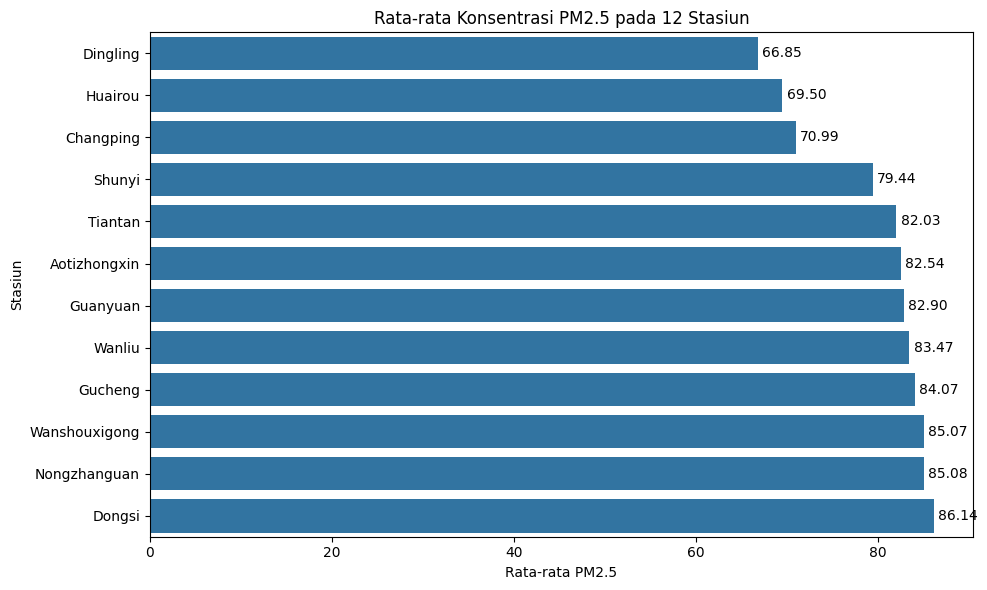

In [29]:
# Menyiapkan data visualisasi
station_plot = station_pm25.sort_values(by="mean", ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=station_plot,
    x="mean",
    y=station_plot.index
)

# Menampilkan nilai rata-rata pada setiap bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Rata-rata Konsentrasi PM2.5 pada 12 Stasiun")
plt.xlabel("Rata-rata PM2.5")
plt.ylabel("Stasiun")
plt.tight_layout()

plt.show()

### Pertanyaan 2:

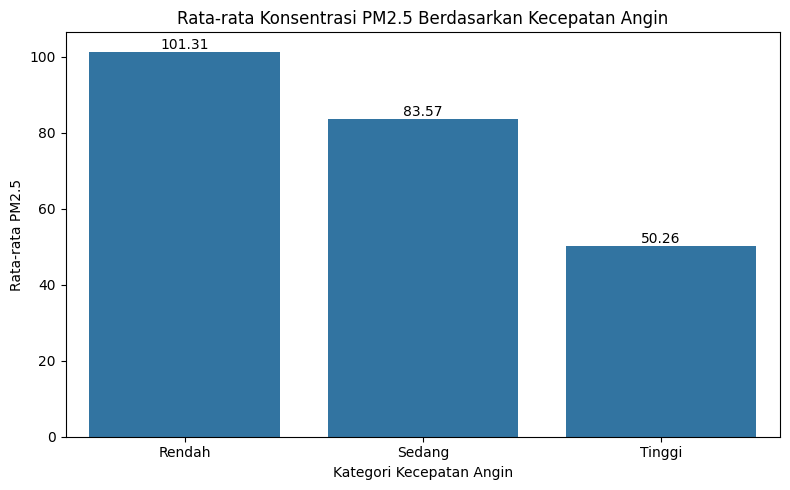

In [27]:
# Menyiapkan data visualisasi
wind_plot = wind_pm25.reset_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=wind_plot,
    x="wind_speed_category",
    y="mean",
    order=["Rendah", "Sedang", "Tinggi"]
)

# Menampilkan nilai pada setiap bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Rata-rata Konsentrasi PM2.5 Berdasarkan Kecepatan Angin")
plt.xlabel("Kategori Kecepatan Angin")
plt.ylabel("Rata-rata PM2.5")
plt.tight_layout()

plt.show()

**Insight:**
- Visualisasi menunjukkan adanya perbedaan rata-rata konsentrasi PM2.5 antarstasiun. Dongsi memiliki rata-rata tertinggi sebesar 86,14, sedangkan Dingling memiliki rata-rata terendah sebesar 66,85 selama periode pengamatan.
- Rata-rata konsentrasi PM2.5 menurun pada kategori kecepatan angin yang lebih tinggi, yaitu 101,31 pada kategori rendah, 83,57 pada kategori sedang, dan 50,26 pada kategori tinggi. Hasil ini menunjukkan adanya asosiasi antara kecepatan angin yang lebih tinggi dan konsentrasi PM2.5 yang lebih rendah.

## Analisis Lanjutan: Binning dan Analisis Korelasi

### Binning Kecepatan Angin

Pada analisis pertanyaan kedua, telah diterapkan teknik **binning** untuk
mengelompokkan variabel kecepatan angin (WSPM) menjadi tiga kategori,
yaitu rendah, sedang, dan tinggi. Teknik ini digunakan untuk mempermudah
perbandingan konsentrasi PM2.5 pada kelompok kondisi kecepatan angin yang
berbeda.

Sebagai analisis tambahan, hubungan antara WSPM dan PM2.5 dianalisis
menggunakan korelasi Spearman. Metode ini digunakan untuk mengukur arah
dan kekuatan hubungan monotonik antara kedua variabel tanpa
mengasumsikan hubungan linear.

In [30]:
# Menghitung korelasi antara WSPM dan PM2.5
correlation = air_quality_df["WSPM"].corr(
    air_quality_df["PM2.5"],
    method="spearman"
)

print(f"Korelasi Spearman WSPM dan PM2.5: {correlation:.3f}")

Korelasi Spearman WSPM dan PM2.5: -0.328


**Insight:**
- Teknik binning menunjukkan bahwa rata-rata PM2.5 menurun dari kategori
  kecepatan angin rendah (101,31), sedang (83,57), hingga tinggi (50,26).
- Hasil analisis menunjukkan nilai korelasi Spearman sebesar -0,328 antara WSPM dan PM2.5. Nilai negatif menunjukkan bahwa kecepatan angin yang lebih tinggi cenderung berkaitan dengan konsentrasi PM2.5 yang lebih rendah.
- Hasil korelasi ini konsisten dengan analisis sebelumnya, di mana kategori kecepatan angin rendah memiliki rata-rata PM2.5 tertinggi. Namun, nilai korelasi tersebut tidak menunjukkan hubungan sebab-akibat dan mengindikasikan bahwa variasi PM2.5 kemungkinan juga berkaitan dengan faktor-faktor lain.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terdapat perbedaan rata-rata konsentrasi PM2.5 pada 12 stasiun selama periode Maret 2013–Februari 2017. Dongsi memiliki rata-rata PM2.5 tertinggi sebesar 86,14, sedangkan Dingling memiliki rata-rata terendah sebesar 66,85. Dengan demikian, Dongsi merupakan stasiun dengan tingkat rata-rata PM2.5 tertinggi dalam periode pengamatan.

- **Conclusion pertanyaan 2:** Konsentrasi PM2.5 menunjukkan perbedaan yang jelas berdasarkan kategori kecepatan angin. Pada kondisi kecepatan angin rendah, rata-rata PM2.5 mencapai 101,31, kemudian menurun menjadi 83,57 pada kategori sedang dan 50,26 pada kategori tinggi. Hasil ini menunjukkan bahwa dalam dataset, kondisi kecepatan angin yang lebih rendah berasosiasi dengan konsentrasi PM2.5 yang lebih tinggi.

**Rekomendasi Action Item:**
- Prioritaskan pemantauan PM2.5 pada stasiun dengan rata-rata konsentrasi relatif tinggi, terutama Dongsi, sehingga peningkatan konsentrasi PM2.5 dapat teridentifikasi lebih cepat.
- Gunakan kondisi kecepatan angin rendah sebagai salah satu indikator untuk meningkatkan kewaspadaan pemantauan kualitas udara, karena periode dengan kategori kecepatan angin rendah dalam data memiliki rata-rata PM2.5 paling tinggi.
- Untuk analisis lanjutan, pertimbangkan variabel meteorologis dan polutan lain seperti temperatur, curah hujan, NO2, dan PM10 untuk memahami faktor yang berkaitan dengan perubahan PM2.5 secara lebih komprehensif.

In [31]:
air_quality_df.to_csv("main_data.csv", index=False)